In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [78]:
# pip install kagglehub[pandas-datasets]

In [79]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

kenpom = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS, 
    "nishaanamin/march-madness-data", 
    "KenPom Barttorvik.csv",
    pandas_kwargs={"usecols": ["YEAR", "TEAM", "KADJ EM", "BARTHAG", "SEED", "ROUND", "QUAD ID"]}
)
heat = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "nishaanamin/march-madness-data",
    "Heat Check Tournament Index.csv",
    pandas_kwargs={"usecols": ["YEAR", "TEAM", "POWER", "PATH", "POOL S-RANK", "NCAA S-RANK"]}
)
shoot = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS, 
    "nishaanamin/march-madness-data", 
    "Shooting Splits.csv",
    pandas_kwargs={"usecols": ["YEAR", "TEAM", "THREES FG%", "THREES FG%D", "THREES SHARE", "CLOSE TWOS FG%", "CLOSE TWOS FG%D", "DUNKS FG%"]}
)

print("\nKenPom Barttorvik\n", kenpom.head())
print("\nHeat Check Ratings\n", heat.head())
print("\nShooting Splits\n", shoot.head())


KenPom Barttorvik
    YEAR  QUAD ID      TEAM  SEED  ROUND  KADJ EM  BARTHAG
0  2026        1     Akron    12      0  12.7986    0.773
1  2026        1   Alabama     4      0  25.7196    0.934
2  2026        2   Arizona     1      0  37.6556    0.978
3  2026        2  Arkansas     4      0  26.0527    0.934
4  2026        2       BYU     6      0  23.2459    0.887

Heat Check Ratings
    YEAR      TEAM  POWER  PATH  POOL S-RANK  NCAA S-RANK
0  2026     Akron   63.2  83.4           47           48
1  2026   Alabama   84.4  72.4           13           14
2  2026   Arizona   94.0  66.1            2            2
3  2026  Arkansas   82.5  67.8           10           16
4  2026       BYU   78.3  72.9           23           24

Shooting Splits
    YEAR      TEAM  DUNKS FG%  CLOSE TWOS FG%  CLOSE TWOS FG%D  THREES FG%  \
0  2026     Akron       93.1            65.0             55.6        38.5   
1  2026   Alabama       85.9            61.4             56.2        35.8   
2  2026   Arizona   

In [80]:
df = kenpom.merge(heat, on=["YEAR", "TEAM"], how="inner").merge(shoot, on=["YEAR", "TEAM"], how="inner")
df.head()

,YEAR,QUAD ID,TEAM,SEED,ROUND,KADJ EM,BARTHAG,POWER,PATH,POOL S-RANK,NCAA S-RANK,DUNKS FG%,CLOSE TWOS FG%,CLOSE TWOS FG%D,THREES FG%,THREES SHARE,THREES FG%D
0,2026,1,Akron,12,0,12.7986,0.773,63.2,83.4,47,48,93.1,65.0,55.6,38.5,45.1,35.1
1,2026,1,Alabama,4,0,25.7196,0.934,84.4,72.4,13,14,85.9,61.4,56.2,35.8,53.7,33.5
2,2026,2,Arizona,1,0,37.6556,0.978,94.0,66.1,2,2,93.4,64.1,52.5,36.0,26.8,31.4
3,2026,2,Arkansas,4,0,26.0527,0.934,82.5,67.8,10,16,92.0,67.1,61.9,38.9,33.4,31.7
4,2026,2,BYU,6,0,23.2459,0.887,78.3,72.9,23,24,84.2,66.9,62.1,34.9,39.8,35.3


In [81]:
# Alternative target: did the team win at least one game? (beat R64?)
# This turns it into binary classification which is much more learnable
# and more directly useful for bracket simulation

df_past = df[df["ROUND"] != 0].copy()
df_2026 = df[df["ROUND"] == 0].copy()

rounds = {64: 1, 32: 2, 16: 3, 8: 4, 4: 5, 2: 6, 1: 7}
df_past["ROUND_ENCODED"] = df_past["ROUND"].map(rounds)

before = len(df_past)
df_past = df_past.dropna(subset=["ROUND_ENCODED"]).copy()
df_past["ROUND_ENCODED"] = df_past["ROUND_ENCODED"].astype(int)
print(f"Dropped {before - len(df_past)} rows with unmapped ROUND values")
print("Class distribution:\n", df_past["ROUND_ENCODED"].value_counts().sort_index())

Dropped 0 rows with unmapped ROUND values
Class distribution:
 ROUND_ENCODED
1    384
2    192
3     96
4     48
5     24
6     12
7     12
Name: count, dtype: int64


In [82]:
X = df_past.drop(columns=["ROUND", "ROUND_ENCODED", "TEAM", "QUAD ID", "YEAR"])
y = df_past["ROUND_ENCODED"]

X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 768 entries, 64 to 831
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   SEED             768 non-null    int64  
 1   KADJ EM          768 non-null    float64
 2   BARTHAG          768 non-null    float64
 3   POWER            768 non-null    float64
 4   PATH             768 non-null    float64
 5   POOL S-RANK      768 non-null    int64  
 6   NCAA S-RANK      768 non-null    int64  
 7   DUNKS FG%        768 non-null    float64
 8   CLOSE TWOS FG%   768 non-null    float64
 9   CLOSE TWOS FG%D  768 non-null    float64
 10  THREES FG%       768 non-null    float64
 11  THREES SHARE     768 non-null    float64
 12  THREES FG%D      768 non-null    float64
dtypes: float64(10), int64(3)
memory usage: 84.0 KB


In [83]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
ct = ColumnTransformer([("scaling", StandardScaler(), ["SEED", "KADJ EM", "BARTHAG", "DUNKS FG%", "CLOSE TWOS FG%", "CLOSE TWOS FG%D", "THREES FG%", "THREES SHARE", "THREES FG%D"])], remainder="passthrough")

In [84]:
models = {"Logistic Regression": Pipeline([("preprocessor", ct), ("classifier", LogisticRegression(max_iter=1000, C=1.0, multi_class="multinomial", solver="lbfgs", class_weight="balanced", random_state=42))]),
    "Random Forest": Pipeline([("preprocessor", ct), ("classifier", RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_split=5, class_weight="balanced", random_state=42, n_jobs=-1))]),
    "Gradient Boosting": Pipeline([("preprocessor", ct), ("classifier", GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=4, subsample=0.8, random_state=42))])
}

In [89]:
ROUND_LABELS = ["R64", "R32", "S16", "E8", "F4", "Final", "Champ"]
results = {}
best_score = 0
best_model = None

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cv = cross_val_score(model, X, y, cv=5, scoring="accuracy")

    if cv.mean() > best_score:
        best_score = cv.mean()
        best_model = model

    results[name] = {
        "model": model,
        "y_pred": y_pred,
        "test_acc": acc,
        "cv_mean": cv.mean(),
        "cv_std": cv.std(),
    }

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"  Test Accuracy : {acc:.4f}")
    print(f"  CV Accuracy   : {cv.mean():.4f} ± {cv.std():.4f}")
    print(f"{'='*50}")
    present_labels = sorted(y_test.unique())
    present_names = [ROUND_LABELS[i - 1] for i in present_labels]
    print(classification_report(y_test, y_pred, labels=present_labels,
                                target_names=present_names, zero_division=0))


  Logistic Regression
  Test Accuracy : 0.3961
  CV Accuracy   : 0.4180 ± 0.0459
              precision    recall  f1-score   support

         R64       0.78      0.64      0.70        77
         R32       0.29      0.18      0.22        39
         S16       0.00      0.00      0.00        19
          E8       0.18      0.20      0.19        10
          F4       0.09      0.40      0.15         5
       Final       0.08      0.50      0.13         2
       Champ       0.00      0.00      0.00         2

    accuracy                           0.40       154
   macro avg       0.20      0.27      0.20       154
weighted avg       0.48      0.40      0.43       154


  Random Forest
  Test Accuracy : 0.4675
  CV Accuracy   : 0.5053 ± 0.0403
              precision    recall  f1-score   support

         R64       0.74      0.62      0.68        77
         R32       0.33      0.38      0.36        39
         S16       0.22      0.26      0.24        19
          E8       0.23     

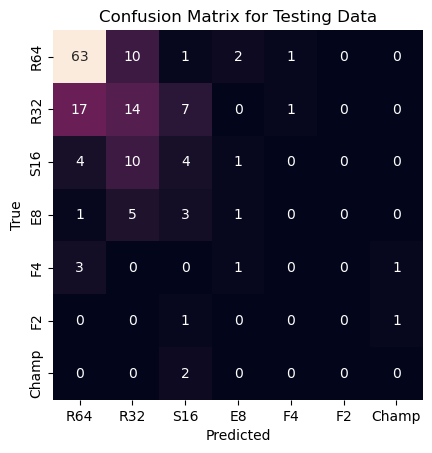

In [93]:
y_test_pred = best_model.predict(X_test)

train_mat = confusion_matrix(y_test, y_test_pred)
sns.heatmap(train_mat, xticklabels=["R64", "R32", "S16", "E8", "F4", "F2", "Champ"], 
            yticklabels=["R64", "R32", "S16", "E8", "F4", "F2", "Champ"], 
            square=True, annot=True, cbar=False, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix for Testing Data")

plt.show()


In [94]:
df_2026.info()

X_2026 = df_2026
y_pred_2026 = best_model.predict(X_2026)

df_2026["prediction"] = y_pred_2026
print(df_2026["prediction"].value_counts())
df_2026[df_2026["prediction"] == 7]

<class 'pandas.core.frame.DataFrame'>
Index: 64 entries, 0 to 63
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YEAR             64 non-null     int64  
 1   QUAD ID          64 non-null     int64  
 2   TEAM             64 non-null     object 
 3   SEED             64 non-null     int64  
 4   ROUND            64 non-null     int64  
 5   KADJ EM          64 non-null     float64
 6   BARTHAG          64 non-null     float64
 7   POWER            64 non-null     float64
 8   PATH             64 non-null     float64
 9   POOL S-RANK      64 non-null     int64  
 10  NCAA S-RANK      64 non-null     int64  
 11  DUNKS FG%        64 non-null     float64
 12  CLOSE TWOS FG%   64 non-null     float64
 13  CLOSE TWOS FG%D  64 non-null     float64
 14  THREES FG%       64 non-null     float64
 15  THREES SHARE     64 non-null     float64
 16  THREES FG%D      64 non-null     float64
 17  prediction       64 non

,YEAR,QUAD ID,TEAM,SEED,ROUND,KADJ EM,BARTHAG,POWER,PATH,POOL S-RANK,NCAA S-RANK,DUNKS FG%,CLOSE TWOS FG%,CLOSE TWOS FG%D,THREES FG%,THREES SHARE,THREES FG%D,prediction
8,2026,4,Duke,1,0,38.8998,0.981,95.0,68.5,1,1,91.5,64.8,54.6,35.1,44.4,30.4,7
